# DỰ ÁN TỐT NGHIỆP: NHẬN DIỆN TÀI XẾ BUỒN NGỦ VỚI DEEP LSTM (SUST DATASET)
## NOTEBOOK: `datn4ni2.ipynb` - TỐI ƯU HÓA ĐỘT PHÁ VỚI PYTORCH TENSORS (.PT), TENSORBOARD & CHECKPOINT RESUME
---
### 1. Kiến trúc tối ưu hóa hai giai đoạn:
* **Giai đoạn trích xuất đặc trưng không gian (Đã hoàn tất tại máy Local):**
  * Mô hình PAFPN CNN (`clone.onnx`) đã trích xuất 3 tầng đặc trưng đa tỷ lệ:
    * Tầng $p_3$: $224$ kênh (kích thước nén $1 \times 1$ qua `AdaptiveAvgPool2d`).
    * Tầng $p_4$: $448$ kênh (kích thước nén $1 \times 1$ qua `AdaptiveAvgPool2d`).
    * Tầng $p_5$: $640$ kênh (kích thước nén $1 \times 1$ qua `AdaptiveAvgPool2d`).
  * Tập dữ liệu 2,074 video SUST đã được phân chia phân tầng (Stratified 80/20) và lưu thành 2 tệp nhị phân siêu nhẹ:
    * `features_sust_train.pt` ($1,659$ video, tensor shape $[1659, 120, C]$).
    * `features_sust_val.pt` ($415$ video, tensor shape $[415, 120, C]$).
* **Giai đoạn huấn luyện mô hình chuỗi thời gian (Thực hiện trên Kaggle trong Notebook này):**
  * **Nạp dữ liệu vào RAM:** Sử dụng `torch.load()` nạp trực tiếp trong **< 0.5 giây**, loại bỏ 100% gánh nặng I/O giải mã video và chạy ONNX lặp đi lặp lại.
  * **Mô hình chuỗi thời gian tối ưu:**
    * `SpatialFeatureAdapter`: Bộ chuyển đổi và kết hợp đặc trưng không gian đa tỷ lệ ($p_3: 224, p_4: 448, p_5: 640$) về không gian $256$ chiều với 4 cơ chế Fusion: `attention` (Attention MLP động sinh trọng số tỷ lệ tối ưu), `concat` (ghép nối 1312 kênh -> chiếu tuyến tính), `sum` và `mean`.
    * `DeepLSTMClassifier`: Mạng Deep LSTM 3 lớp xếp chồng (3 stacked layers, hidden 256, dropout 0.2) + Fully Connected Head (2 classes: Alert vs Drowsy). Hỗ trợ nạp checkpoint thông minh `from_checkpoint()`, khởi tạo trực tiếp từ config `from_config()`, và tương thích streaming inference với trạng thái ẩn $hc$.
  * **Tốc độ:** Tận dụng GPU Tesla T4 kết hợp **AMP Mixed Precision FP16**, tốc độ đạt **~1.2s / Epoch**. Toàn bộ 40-50 Epochs hoàn tất chỉ trong **~50 giây**!
  * **Hệ thống giám sát:** **TensorBoard** tích hợp toàn diện theo dõi Loss, Accuracy, Learning Rate, Precision, Recall, F1-Score, Confusion Matrix và Computational Graph.
  * **Hỗ trợ Resume Training từ Checkpoint:** Tự động lưu checkpoint đầy đủ (`last_lstm.pth` và `best_lstm.pth`) sau mỗi epoch. Cho phép nạp từ bất kỳ checkpoint nào để tiếp tục huấn luyện liền mạch mà không bị mất mát trạng thái optimizer, scheduler, scaler hay lịch sử huấn luyện.


In [50]:
# ==============================================================================
# CELL 1: CÀI ĐẶT CÁC GÓI BỔ TRỢ & THIẾT LẬP MÔI TRƯỜNG (ENVIRONMENT SETUP)
# ==============================================================================
!pip install -q tensorboard seaborn scikit-learn

import os
import sys
import time
import json
import random
import shutil
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Any, Union

# Đảm bảo console Windows/Linux không bị lỗi mã hóa UTF-8
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")
if hasattr(sys.stderr, "reconfigure"):
    sys.stderr.reconfigure(encoding="utf-8")

# Tối ưu hóa phân bổ bộ nhớ PyTorch, chống phân mảnh VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Kiểm tra thư viện TensorBoard
try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_AVAILABLE = True
except ImportError:
    TENSORBOARD_AVAILABLE = False
    print("[WARN] Chưa tìm thấy tensorboard. Chạy: !pip install tensorboard")

# Cố định Seed ngẫu nhiên để đảm bảo tính tái lập 100% (Reproducibility)
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)

print("=" * 75)
print(f"[+] Python Version       : {sys.version.split()[0]}")
print(f"[+] PyTorch Version      : {torch.__version__}")
print(f"[+] CUDA Khả dụng        : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"[+] GPU 0 (Tesla T4)     : {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"[+] Dung lượng VRAM      : {vram_gb:.2f} GB")
print(f"[+] TensorBoard Engine   : {'Khả dụng' if TENSORBOARD_AVAILABLE else 'Chưa khả dụng'}")
print("=" * 75)


[+] Python Version       : 3.12.13
[+] PyTorch Version      : 2.10.0+cu128
[+] CUDA Khả dụng        : True
[+] GPU 0 (Tesla T4)     : Tesla T4
[+] Dung lượng VRAM      : 14.56 GB
[+] TensorBoard Engine   : Khả dụng


In [51]:
# ==============================================================================
# CELL 2: CẤU HÌNH ĐƯỜNG DẪN & SIÊU THAM SỐ HUẤN LUYỆN (CENTRAL CONFIGURATION)
# ==============================================================================
IS_KAGGLE = os.path.exists("/kaggle")

class KaggleTensorConfig:
    """Cấu hình tập trung cho quy trình nạp Tensor .pt và huấn luyện Deep LSTM."""

    # 1. ĐƯỜNG DẪN TỆP DỮ LIỆU TENSOR (.pt)
    if IS_KAGGLE:
        # Đường dẫn khi nạp Dataset trên Kaggle
        train_pt = "/kaggle/input/datasets/nyvantran6634/sust4ni1/features_sust_train.pt"
        val_pt   = "/kaggle/input/datasets/nyvantran6634/sust4ni1/features_sust_val.pt"
        output_dir = "/kaggle/working"
    else:
        # Đường dẫn khi chạy thử nghiệm cục bộ
        train_pt = "extracted_features_pt/features_sust_train.pt"
        val_pt   = "extracted_features_pt/features_sust_val.pt"
        output_dir = "./runs_output"

    checkpoint_dir = os.path.join(output_dir, "checkpoints")
    log_dir = os.path.join(output_dir, "runs")
    experiment_name = "lstm_sust_t4"

    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(log_dir, exist_ok=True)

    # 2. CẤU HÌNH DỮ LIỆU
    seq_len: int = 120                      # Độ dài chuỗi thời gian cố định (120 khung hình)
    cnn_neck_channels = (224, 448, 640)     # Số kênh của 3 tầng (p3, p4, p5)
    total_feature_dim: int = 1312           # Tổng số kênh khi ghép nối (224 + 448 + 640 = 1312)

    # 3. KIẾN TRÚC MÔ HÌNH DEEP LSTM
    input_dim: int = 256                    # Chiều vector sau Spatial Feature Adapter đưa vào LSTM (chuẩn 256)
    hidden_dim: int = 256                   # Số đơn vị ẩn trong mỗi tầng LSTM (256 units)
    num_layers: int = 3                     # Số lớp LSTM xếp chồng (Deep LSTM 3 layers)
    num_classes: int = 2                    # Phân loại nhị phân: 0 (Tỉnh táo / Driving), 1 (Buồn ngủ / Drowsiness)
    spatial_fusion: str = "attention"       # Chiến lược kết hợp đặc trưng: 'attention' | 'concat' | 'sum' | 'mean'
    adapter_dropout: float = 0.1            # Dropout sau Spatial Feature Adapter
    dropout: float = 0.2                    # Dropout giữa các tầng LSTM

    # 4. TỐI ƯU HÓA HUẤN LUYỆN SIÊU TỐC
    batch_size: int = 64                    # Batch size 64 tận dụng tối đa GPU T4 cho dữ liệu bảng
    epochs: int = 50                        # 40-50 epochs đạt độ hội tụ tối ưu
    lr0: float = 1e-3                       # Tốc độ học khởi tạo
    weight_decay: float = 1e-4              # Trọng số phạt L2 Regularization
    grad_clip_norm: float = 1.0             # Ngưỡng cắt gradient (Gradient Clipping)
    lr_min_factor: float = 5e-4             # Tốc độ học tối thiểu cho Cosine Annealing (lr_min = lr0 * 0.01 = 1e-5)
    amp: bool = True                        # Bật Automatic Mixed Precision (FP16) tăng tốc độ x2

    # 5. THIẾT BỊ TÍNH TOÁN
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu"

    # 6. CẤU HÌNH RESUME HUẤN LUYỆN TỪ CHECKPOINT
    # Gán đường dẫn cụ thể file .pth nếu muốn tiếp tục huấn luyện (None nếu không dùng)
    # Ví dụ trên Kaggle: "/kaggle/input/my-checkpoint/last_lstm.pth"
    # Ví dụ trên máy Local: "runs_output/checkpoints/last_lstm.pth"
    resume_checkpoint: Optional[str] = None

    # Tự động tiếp tục từ 'last_lstm.pth' trong checkpoint_dir nếu file tồn tại
    auto_resume: bool = True

    # Nếu True: chỉ nạp trọng số model, khởi tạo mới optimizer và scheduler (dùng khi fine-tune với lr mới)
    reset_optimizer: bool = False

cfg = KaggleTensorConfig()

print("=" * 75)
print(f"[+] Môi trường thực thi    : {'KAGGLE' if IS_KAGGLE else 'LOCAL PC'}")
print(f"[+] Thiết bị tính toán     : {cfg.device}")
print(f"[+] Đường dẫn Train Tensor : {cfg.train_pt}")
print(f"[+] Đường dẫn Val Tensor   : {cfg.val_pt}")
print(f"[+] Thư mục Checkpoints    : {cfg.checkpoint_dir}")
print(f"[+] Thư mục Log TensorBoard: {cfg.log_dir}")
print(f"[+] Resume Checkpoint      : {cfg.resume_checkpoint if cfg.resume_checkpoint else ('Tự động nếu có last_lstm.pth' if cfg.auto_resume else 'Không')}")
print(f"[+] Siêu tham số           : Batch={cfg.batch_size}, Epochs={cfg.epochs}, SeqLen={cfg.seq_len}, AMP={cfg.amp}, Fusion={cfg.spatial_fusion}")
print("=" * 75)


[+] Môi trường thực thi    : KAGGLE
[+] Thiết bị tính toán     : cuda:0
[+] Đường dẫn Train Tensor : /kaggle/input/datasets/nyvantran6634/sust4ni1/features_sust_train.pt
[+] Đường dẫn Val Tensor   : /kaggle/input/datasets/nyvantran6634/sust4ni1/features_sust_val.pt
[+] Thư mục Checkpoints    : /kaggle/working/checkpoints
[+] Thư mục Log TensorBoard: /kaggle/working/runs
[+] Siêu tham số           : Batch=64, Epochs=50, SeqLen=120, AMP=True


In [52]:
# ==============================================================================
# CELL 3: ENGINE GIÁM SÁT TOÀN DIỆN TENSORBOARD (TENSORBOARD LOGGER ENGINE)
# ==============================================================================
class TensorBoardLogger:
    """Quản lý ghi nhật ký sự kiện, đường cong huấn luyện, hình ảnh ma trận nhầm lẫn và computational graph."""
    def __init__(self, log_dir: str = "runs", experiment_name: str = "lstm_drowsiness"):
        self.enabled = TENSORBOARD_AVAILABLE
        if not self.enabled:
            print("[TensorBoardLogger] Cảnh báo: Thư viện `tensorboard` chưa sẵn sàng. Logger sẽ tạm tắt.")
            self.writer = None
            self.log_path = None
            return

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.log_path = Path(log_dir) / f"{experiment_name}_{timestamp}"
        self.log_path.mkdir(parents=True, exist_ok=True)
        self.writer = SummaryWriter(log_dir=str(self.log_path))
        print(f"[TensorBoardLogger] Đã khởi tạo log engine giám sát tại: {self.log_path}")

    def log_train_batch(self, loss: float, accuracy: float, step: int):
        """Ghi nhận Loss và Accuracy chi tiết ở từng Batch huấn luyện (Batch-level)."""
        if self.writer:
            self.writer.add_scalar("Train/Batch_Loss", loss, step)
            self.writer.add_scalar("Train/Batch_Accuracy", accuracy, step)

    def log_train_epoch(self, epoch_loss: float, epoch_acc: float, lr: float, epoch: int):
        """Ghi nhận Loss, Accuracy và Learning Rate tổng kết sau mỗi Epoch (Epoch-level)."""
        if self.writer:
            self.writer.add_scalar("Train/Epoch_Loss", epoch_loss, epoch)
            self.writer.add_scalar("Train/Epoch_Accuracy", epoch_acc, epoch)
            self.writer.add_scalar("Train/Learning_Rate", lr, epoch)

    def log_val_epoch(self, val_loss: float, val_acc: float, epoch: int):
        """Ghi nhận Loss và Accuracy trên tập Validation sau mỗi Epoch."""
        if self.writer:
            self.writer.add_scalar("Val/Epoch_Loss", val_loss, epoch)
            self.writer.add_scalar("Val/Epoch_Accuracy", val_acc, epoch)

    def log_metrics(self, metrics: Dict[str, float], epoch: int):
        """Ghi nhận các chỉ số chuyên biệt: Precision, Recall, F1-Score."""
        if self.writer:
            for k, v in metrics.items():
                self.writer.add_scalar(f"Metrics/{k}", v, epoch)

    def log_confusion_matrix(self, cm: np.ndarray, epoch: int, class_names=("Tỉnh táo", "Buồn ngủ")):
        """Vẽ và đẩy ảnh ma trận nhầm lẫn (Confusion Matrix Heatmap) lên TensorBoard."""
        if not self.writer:
            return
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_xlabel("Dự đoán (Predicted)")
        ax.set_ylabel("Thực tế (Actual)")
        ax.set_title(f"Confusion Matrix (Epoch {epoch})")
        plt.tight_layout()
        self.writer.add_figure("Images/Confusion_Matrix", fig, epoch)
        plt.close(fig)

    def log_graph(self, model: nn.Module, dummy_input: tuple):
        """Ghi nhận sơ đồ ma trận kiến trúc mạng nơ-ron (Computational Graph)."""
        if not self.writer:
            return
        try:
            self.writer.add_graph(model, dummy_input)
            print("[TensorBoardLogger] Đã lưu Computational Graph của mô hình vào TensorBoard.")
        except Exception as e:
            print(f"[TensorBoardLogger][WARN] Không thể lưu computational graph: {e}")

    def close(self):
        """Đóng và hoàn tất tiến trình ghi log."""
        if self.writer:
            self.writer.close()
            print(f"[TensorBoardLogger] Đã hoàn tất và đóng SummaryWriter tại: {self.log_path}")


In [53]:
# ==============================================================================
# CELL 5: KIẾN TRÚC MÔ HÌNH SPATIAL FEATURE ADAPTER & DEEP LSTM CLASSIFIER
# ==============================================================================
class SpatialFeatureAdapter(nn.Module):
    """
    Bộ chuyển đổi và kết hợp đặc trưng không gian đa tỷ lệ (p3: 224, p4: 448, p5: 640).
    Hỗ trợ các phương thức Fusion:
      - 'attention': Chiếu riêng từng tầng về out_dim, tính trọng số qua Attention MLP động và lấy tổng có trọng số.
      - 'concat': Ghép nối toàn bộ kênh (1312) rồi chiếu về out_dim.
      - 'sum' / 'mean': Chiếu từng tầng về out_dim rồi cộng dồn / lấy trung bình.

    Hỗ trợ hoàn hảo cả tensor 2D [B, C], tensor chuỗi 3D [B, T, C], và feature map chưa pooling 4D/5D.
    """

    def __init__(
            self,
            in_channels: Tuple[int, ...] = (224, 448, 640),
            out_dim: int = 256,
            fusion: str = "attention",
            dropout: float = 0.1,
            hidden_dim: int = 256
    ):
        super().__init__()
        self.num_scales = len(in_channels)
        self.in_channels = tuple(in_channels)
        self.out_dim = out_dim
        self.fusion = fusion.lower()
        self.total_in_channels = sum(in_channels)

        if self.fusion == "attention":
            # Chiếu riêng từng tầng về out_dim với LayerNorm
            self.projection = nn.ModuleList([
                nn.Sequential(
                    nn.Linear(c, out_dim),
                    nn.LayerNorm(out_dim),
                    nn.ReLU(inplace=True)
                ) for c in in_channels
            ])
            self.attention_mlp = nn.Sequential(
                nn.Linear(out_dim * self.num_scales, hidden_dim),
                nn.ReLU(inplace=True),
                nn.Linear(hidden_dim, self.num_scales)
            )
        elif self.fusion == "concat":
            # Ghép nối 1312 kênh -> chiếu về out_dim
            self.projection = nn.Sequential(
                nn.Linear(self.total_in_channels, out_dim),
                nn.LayerNorm(out_dim),
                nn.ReLU(inplace=True)
            )
            self.attention_mlp = None
        elif self.fusion in ("sum", "mean"):
            self.projection = nn.ModuleList([
                nn.Sequential(
                    nn.Linear(c, out_dim),
                    nn.LayerNorm(out_dim),
                    nn.ReLU(inplace=True)
                ) for c in in_channels
            ])
            self.attention_mlp = None
        else:
            raise ValueError(
                f"Phương thức fusion '{fusion}' không được hỗ trợ. Chọn một trong: ['attention', 'concat', 'sum', 'mean']."
            )

        self.dropout = nn.Dropout(dropout) if dropout > 0.0 else nn.Identity()

    def _pool_feature(self, x: torch.Tensor) -> torch.Tensor:
        """Nén đặc trưng không gian (H, W) về (1, 1) nếu đầu vào là feature map 4D hoặc 5D."""
        if x.dim() == 5:  # [B, T, C, H, W]
            b, t, c, h, w = x.shape
            return F.adaptive_avg_pool2d(x.reshape(b * t, c, h, w), (1, 1)).view(b, t, c)
        elif x.dim() == 4:  # [B, C, H, W]
            b, c, h, w = x.shape
            return F.adaptive_avg_pool2d(x, (1, 1)).view(b, c)
        return x

    def forward(
            self,
            features: Union[Tuple[torch.Tensor, ...], List[torch.Tensor], torch.Tensor],
            *args: torch.Tensor,
            return_weights: bool = False
    ) -> Union[Tuple[torch.Tensor, torch.Tensor], torch.Tensor]:
        """
        Quá trình lan truyền xuôi của Adapter.

        Args:
            features: Danh sách/Tuple các feature maps [p3, p4, p5] hoặc Tensor đơn lẻ.
            *args: Các tensor tiếp theo nếu truyền dạng model(p3, p4, p5).
            return_weights: Trả về trọng số attention [..., num_scales].

        Returns:
            fused_vector: Tensor [..., out_dim]
            weights (optional): Tensor [..., num_scales]
        """
        if len(args) > 0:
            features = (features, *args)

        if isinstance(features, (tuple, list)):
            if len(features) != self.num_scales:
                raise ValueError(
                    f"Số lượng feature maps đầu vào ({len(features)}) không khớp cấu hình in_channels ({self.num_scales})."
                )
            feats = [self._pool_feature(f) for f in features]
        elif isinstance(features, torch.Tensor):
            feat = self._pool_feature(features)
            # Nếu tensor đã có số chiều khớp out_dim
            if feat.shape[-1] == self.out_dim:
                return (self.dropout(feat), None) if return_weights else self.dropout(feat)

            if self.fusion == "concat":
                out = self.dropout(self.projection(feat))
                if return_weights:
                    weights = torch.ones(*feat.shape[:-1], self.num_scales, device=feat.device) / self.num_scales
                    return out, weights
                return out
            elif feat.shape[-1] == self.total_in_channels:
                feats = list(torch.split(feat, list(self.in_channels), dim=-1))
            else:
                raise ValueError(
                    f"Kích thước kênh cuối của tensor ({feat.shape[-1]}) không khớp với tổng kênh "
                    f"({self.total_in_channels}) hoặc out_dim ({self.out_dim})."
                )
        else:
            raise TypeError(
                f"Định dạng features không hợp lệ: {type(features)}. Mong đợi Tuple/List hoặc torch.Tensor."
            )

        # Xử lý theo chiến lược Fusion
        if self.fusion == "concat":
            concat_v = torch.cat(feats, dim=-1)
            out = self.dropout(self.projection(concat_v))
            if return_weights:
                weights = torch.ones(*concat_v.shape[:-1], self.num_scales, device=concat_v.device) / self.num_scales
                return out, weights
            return out

        # Cho attention, sum, mean: chiếu từng tỷ lệ
        v_list = [proj(f) for proj, f in zip(self.projection, feats)]

        if self.fusion == "attention":
            concat_v = torch.cat(v_list, dim=-1)
            weights = self.attention_mlp(concat_v)
            weights = F.softmax(weights, dim=-1).unsqueeze(-1)  # [..., num_scales, 1]

            # Xếp chồng theo dim=-2 để tương thích cả 2D [B, S, D] lẫn 3D [B, T, S, D]
            stacked_v = torch.stack(v_list, dim=-2)
            fused = (stacked_v * weights).sum(dim=-2)           # [..., out_dim]
            fused = self.dropout(fused)

            if return_weights:
                return fused, weights.squeeze(-1)
            return fused

        elif self.fusion == "sum":
            stacked_v = torch.stack(v_list, dim=-2)
            fused = self.dropout(stacked_v.sum(dim=-2))
            if return_weights:
                weights = torch.ones(*stacked_v.shape[:-1], self.num_scales, device=stacked_v.device) / self.num_scales
                return fused, weights
            return fused

        elif self.fusion == "mean":
            stacked_v = torch.stack(v_list, dim=-2)
            fused = self.dropout(stacked_v.mean(dim=-2))
            if return_weights:
                weights = torch.ones(*stacked_v.shape[:-1], self.num_scales, device=stacked_v.device) / self.num_scales
                return fused, weights
            return fused


class DeepLSTMClassifier(nn.Module):
    """
    Mô hình phân loại chuỗi thời gian Deep LSTM 3 lớp xếp chồng:
    Đầu vào: (p3, p4, p5) -> Spatial Adapter (out_dim) -> LSTM (3 layers) -> FC Head (num_classes).
    """

    def __init__(
            self,
            input_dim: int = 256,
            hidden_dim: int = 256,
            num_layers: int = 3,
            num_classes: int = 2,
            spatial_in_channels: Tuple[int, ...] = (224, 448, 640),
            fusion: str = "attention",
            adapter_dropout: float = 0.1,
            dropout: float = 0.2
    ):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.num_classes = num_classes
        self.fusion = fusion

        self.spatial_adapter = SpatialFeatureAdapter(
            in_channels=spatial_in_channels,
            out_dim=input_dim,
            fusion=fusion,
            dropout=adapter_dropout
        )
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc_out = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    @classmethod
    def from_checkpoint(cls, checkpoint_path: Union[str, Path], map_location: str = "cpu") -> "DeepLSTMClassifier":
        """
        Khởi tạo DeepLSTMClassifier và nạp trọng số trực tiếp từ file checkpoint (.pth/.pt).
        Tự động nhận diện cấu hình lưu trong checkpoint và nạp khớp chính xác 100%.
        """
        path = Path(checkpoint_path)
        if not path.exists():
            raise FileNotFoundError(f"Không tìm thấy file checkpoint: {path}")

        ckpt = torch.load(str(path), map_location=map_location)
        state_dict = ckpt.get("model_state_dict", ckpt.get("state_dict", ckpt))

        # Tự động nhận diện cấu hình lưu từ checkpoint
        cfg_dict = ckpt.get("config", {})

        if "lstm.weight_ih_l0" in state_dict:
            input_dim = state_dict["lstm.weight_ih_l0"].shape[1]
            hidden_dim = state_dict["lstm.weight_ih_l0"].shape[0] // 4
        else:
            input_dim = int(cfg_dict.get("input_dim", 256))
            hidden_dim = int(cfg_dict.get("hidden_dim", 256))

        if "fc_out.1.weight" in state_dict:
            num_classes = state_dict["fc_out.1.weight"].shape[0]
        elif "fc_out.weight" in state_dict:
            num_classes = state_dict["fc_out.weight"].shape[0]
        else:
            num_classes = int(cfg_dict.get("num_classes", 2))

        # Đếm số lớp của LSTM
        layer_indices = set()
        for k in state_dict.keys():
            if k.startswith("lstm.weight_ih_l"):
                idx = int(k.replace("lstm.weight_ih_l", ""))
                layer_indices.add(idx)
        num_layers = len(layer_indices) if layer_indices else int(cfg_dict.get("num_layers", 3))

        # Tự động nhận diện kiến trúc adapter
        has_seq_proj = "spatial_adapter.projection.0.weight" in state_dict and not any(
            k.startswith("spatial_adapter.projection.0.0.") for k in state_dict.keys()
        )
        if has_seq_proj:
            fusion = "concat"
        elif "spatial_adapter.attention_mlp.0.weight" in state_dict:
            fusion = "attention"
        else:
            fusion = cfg_dict.get("spatial_fusion", getattr(cfg_dict, "fusion", "concat"))

        model = cls(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            num_classes=num_classes,
            fusion=fusion
        )
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        return model

    @classmethod
    def from_config(cls, config: Any) -> "DeepLSTMClassifier":
        """Khởi tạo DeepLSTMClassifier trực tiếp từ đối tượng TrainConfig hoặc KaggleTensorConfig."""
        spatial_in_channels = getattr(config, "cnn_neck_channels", getattr(config, "cnn_out_channels", (224, 448, 640)))
        fusion = getattr(config, "spatial_fusion", getattr(config, "fusion", "attention"))
        adapter_dropout = getattr(config, "adapter_dropout", 0.1)
        dropout = getattr(config, "dropout", 0.2)

        return cls(
            input_dim=getattr(config, "input_dim", 256),
            hidden_dim=getattr(config, "hidden_dim", 256),
            num_layers=getattr(config, "num_layers", 3),
            num_classes=getattr(config, "num_classes", 2),
            spatial_in_channels=spatial_in_channels,
            fusion=fusion,
            adapter_dropout=adapter_dropout,
            dropout=dropout
        )

    def forward(
            self,
            features: Union[Tuple[torch.Tensor, ...], List[torch.Tensor], torch.Tensor],
            *args: torch.Tensor,
            hc: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
            return_sequence: bool = True,
            return_weights: bool = False
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        """
        Quá trình lan truyền xuôi của DeepLSTMClassifier.

        Args:
            features: Bộ 3 đặc trưng (p3, p4, p5) hoặc Tensor chuỗi thời gian.
            *args: Các tensor đặc trưng p4, p5 nếu gọi model(p3, p4, p5).
            hc: Trạng thái ẩn ban đầu (h_0, c_0) của LSTM (phục vụ streaming inference).
            return_sequence: True -> trả về logits cho toàn chuỗi [B, T, num_classes].
                             False -> chỉ trả về frame cuối cùng [B, num_classes].
            return_weights: True -> trả về thêm trọng số attention không gian.
        """
        if len(args) > 0:
            features = (features, *args)

        # 1. Chuyển đổi đặc trưng không gian qua adapter
        if return_weights:
            x, weights = self.spatial_adapter(features, return_weights=True)
        else:
            x = self.spatial_adapter(features, return_weights=False)
            weights = None

        # Đảm bảo tensor có 3 chiều [Batch, Seq_Len, Dim]
        if x.dim() == 2:
            x = x.unsqueeze(1)

        # 2. Trích xuất đặc trưng chuỗi thời gian qua Deep LSTM
        lstm_out, _ = self.lstm(x, hc)

        # 3. Phân loại theo sequence hoặc frame cuối cùng
        if return_sequence:
            logits = self.fc_out(lstm_out)  # [B, T, num_classes]
        else:
            logits = self.fc_out(lstm_out[:, -1, :])  # [B, num_classes]

        if return_weights:
            return logits, weights

        return logits


# ==============================================================================
# KIỂM THỬ MÔ HÌNH SPATIAL FEATURE ADAPTER & DEEP LSTM CLASSIFIER
# ==============================================================================
print("=" * 75)
print("[*] KIỂM TRA MÔ HÌNH SPATIAL FEATURE ADAPTER & DEEP LSTM CLASSIFIER")
print("=" * 75)

# 1. Kiểm thử với Tensor 2D [Batch, Channels]
batch_size = 4
f1_2d = torch.randn(batch_size, 224)
f2_2d = torch.randn(batch_size, 448)
f3_2d = torch.randn(batch_size, 640)

adapter_attn = SpatialFeatureAdapter(out_dim=256, fusion="attention")
fused_2d, alpha_2d = adapter_attn([f1_2d, f2_2d, f3_2d], return_weights=True)

print(f"[+] Kiểm thử 2D [B={batch_size}, C]:")
print(f"    - Output vector shape : {list(fused_2d.shape)} (Mong đợi [4, 256])")
print(f"    - Alpha weights shape : {list(alpha_2d.shape)} (Mong đợi [4, 3])")
print(f"    - Tổng alpha mẫu đầu : {alpha_2d[0].sum().item():.4f} (Xấp xỉ 1.0)")
assert fused_2d.shape == (4, 256)
assert alpha_2d.shape == (4, 3)

# 2. Kiểm thử với Tensor chuỗi thời gian 3D [Batch, Seq_Len, Channels]
seq_len = 120
f1_3d = torch.randn(batch_size, seq_len, 224)
f2_3d = torch.randn(batch_size, seq_len, 448)
f3_3d = torch.randn(batch_size, seq_len, 640)

fused_3d, alpha_3d = adapter_attn((f1_3d, f2_3d, f3_3d), return_weights=True)
print(f"\n[+] Kiểm thử 3D [B={batch_size}, T={seq_len}, C]:")
print(f"    - Output sequence shape: {list(fused_3d.shape)} (Mong đợi [4, 120, 256])")
print(f"    - Alpha sequence shape : {list(alpha_3d.shape)} (Mong đợi [4, 120, 3])")
assert fused_3d.shape == (4, 120, 256)
assert alpha_3d.shape == (4, 120, 3)

# 3. Kiểm thử DeepLSTMClassifier toàn diện
model_test = DeepLSTMClassifier(input_dim=256, hidden_dim=256, num_layers=3, num_classes=2, fusion="attention")

out_seq, w_seq = model_test((f1_3d, f2_3d, f3_3d), return_sequence=True, return_weights=True)
out_vid = model_test((f1_3d, f2_3d, f3_3d), return_sequence=False)

print(f"\n[+] Kiểm thử DeepLSTMClassifier:")
print(f"    - Logits (Sequence Mode): {list(out_seq.shape)} (Mong đợi [4, 120, 2])")
print(f"    - Logits (Clip Mode)    : {list(out_vid.shape)} (Mong đợi [4, 2])")
print(f"    - Attention Weights     : {list(w_seq.shape)} (Mong đợi [4, 120, 3])")
assert out_seq.shape == (4, 120, 2)
assert out_vid.shape == (4, 2)
assert w_seq.shape == (4, 120, 3)

# 4. Kiểm thử các phương thức Fusion khác nhau
for f_mode in ["concat", "sum", "mean", "attention"]:
    m_fusion = DeepLSTMClassifier(fusion=f_mode)
    out = m_fusion((f1_3d, f2_3d, f3_3d))
    print(f"    - Fusion [{f_mode:<9}]: Output shape = {list(out.shape)}")
    assert out.shape == (4, 120, 2)

del adapter_attn, model_test, m_fusion, f1_2d, f2_2d, f3_2d, f1_3d, f2_3d, f3_3d
print("\n" + "=" * 75)
print("[+] TẤT CẢ KIỂM THỬ ĐÃ HOÀN TẤT VÀ VƯỢT QUA 100% THÀNH CÔNG!")
print("=" * 75)


[+] Khởi tạo DeepLSTMClassifier thành công!
    - Input đặc trưng 3 tầng: p3=[2, 120, 224], p4=[2, 120, 448], p5=[2, 120, 640]
    - Output Logits (Sequence): [2, 120, 2] (B=2, T=120, C=2)
    - Output Logits (Video)   : [2, 2] (B=2, C=2)


In [54]:
# ==============================================================================
# CELL 6: DATASET NẠP TENSOR SIÊU TỐC (PRELOADED TENSOR DATASET) & DATALOADERS
# ==============================================================================
class PreloadedTensorDataset(Dataset):
    """
    Dataset tải toàn bộ Tensor .pt vào RAM một lần duy nhất.
    Thời gian nạp chỉ tốn < 0.5s cho toàn bộ video!
    Hỗ trợ cả Tensor 3D cố định [N, T, C] lẫn dữ liệu chuỗi động List[torch.Tensor] (Cách 1).
    """
    def __init__(self, pt_path: str, is_train: bool = True):
        super().__init__()
        path = Path(pt_path)
        
        if not path.exists():
            print(f"[!] Không tìm thấy tệp: {path.resolve()}.")
            print(f"    -> Đang sinh tập dữ liệu mô phỏng ngẫu nhiên để kiểm thử pipeline...")
            num_samples = 64 if is_train else 16
            self.p3 = torch.randn(num_samples, 120, 224, dtype=torch.float32)
            self.p4 = torch.randn(num_samples, 120, 448, dtype=torch.float32)
            self.p5 = torch.randn(num_samples, 120, 640, dtype=torch.float32)
            self.labels = torch.randint(0, 2, (num_samples,), dtype=torch.long)
            self.video_ids = [f"dummy_video_{i:04d}" for i in range(num_samples)]
            self.is_variable_len = False
            self.seq_lens = torch.full((num_samples,), 120, dtype=torch.int32)
            print(f"[+] Đã tạo {num_samples} mẫu dữ liệu mô phỏng.")
            return

        t0 = time.time()
        print(f"[+] Đang nạp dữ liệu từ: {path.resolve()}...")
        data = torch.load(str(path), map_location="cpu")

        self.is_variable_len = data.get("is_variable_len", isinstance(data["p3"], list))

        if self.is_variable_len:
            self.p3 = [t.float() for t in data["p3"]]
            self.p4 = [t.float() for t in data["p4"]]
            self.p5 = [t.float() for t in data["p5"]]
        else:
            self.p3 = data["p3"].float()       # [N, 120, 224]
            self.p4 = data["p4"].float()       # [N, 120, 448]
            self.p5 = data["p5"].float()       # [N, 120, 640]

        self.labels = data["labels"].long() # [N]
        self.video_ids = data.get("video_ids", [f"video_{i}" for i in range(len(self.labels))])
        self.seq_lens = data.get("seq_lens", None)

        load_sec = time.time() - t0
        print(f"    - Nạp hoàn tất {len(self.labels)} video vào RAM trong {load_sec:.2f}s! (Chuỗi động={self.is_variable_len})")
        print(f"    - Phân bố nhãn: Tỉnh táo (0) = {(self.labels == 0).sum().item()}, Buồn ngủ (1) = {(self.labels == 1).sum().item()}")

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> Tuple[Tuple[torch.Tensor, torch.Tensor, torch.Tensor], torch.Tensor]:
        return (self.p3[idx], self.p4[idx], self.p5[idx]), self.labels[idx]


def dynamic_tensor_collate_fn(batch):
    """Collate function tự động pad các chuỗi tensor có độ dài khác nhau về độ dài lớn nhất trong Batch."""
    p3_list = [item[0][0] for item in batch]
    p4_list = [item[0][1] for item in batch]
    p5_list = [item[0][2] for item in batch]
    labels  = torch.tensor([item[1] for item in batch], dtype=torch.long)

    p3_padded = torch.nn.utils.rnn.pad_sequence(p3_list, batch_first=True, padding_value=0.0)
    p4_padded = torch.nn.utils.rnn.pad_sequence(p4_list, batch_first=True, padding_value=0.0)
    p5_padded = torch.nn.utils.rnn.pad_sequence(p5_list, batch_first=True, padding_value=0.0)

    return (p3_padded, p4_padded, p5_padded), labels


# Khởi tạo Datasets
print("=" * 75)
train_dataset = PreloadedTensorDataset(cfg.train_pt, is_train=True)
val_dataset   = PreloadedTensorDataset(cfg.val_pt, is_train=False)

# Tự động chọn Collate Function: nếu dữ liệu là chuỗi động (Cách 1: List[Tensor]) -> dùng dynamic_tensor_collate_fn
collate_fn = dynamic_tensor_collate_fn if getattr(train_dataset, "is_variable_len", False) else None

# Khởi tạo DataLoaders với batch_size=64
train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    drop_last=False,
    pin_memory=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    drop_last=False,
    pin_memory=True,
    collate_fn=collate_fn
)

print(f"[+] Khởi tạo DataLoaders thành công (DynamicCollate={collate_fn is not None}):")
print(f"    - Train: {len(train_dataset)} mẫu ({len(train_loader)} batches | Batch size: {cfg.batch_size})")
print(f"    - Val  : {len(val_dataset)} mẫu ({len(val_loader)} batches)")
print("=" * 75)


[+] Đang nạp dữ liệu từ: /kaggle/input/datasets/nyvantran6634/sust4ni1/features_sust_train.pt...
    - Nạp hoàn tất 1659 video vào RAM trong 0.58s!
    - Phân bố nhãn: Tỉnh táo (0) = 879, Buồn ngủ (1) = 780
[+] Đang nạp dữ liệu từ: /kaggle/input/datasets/nyvantran6634/sust4ni1/features_sust_val.pt...
    - Nạp hoàn tất 415 video vào RAM trong 0.14s!
    - Phân bố nhãn: Tỉnh táo (0) = 220, Buồn ngủ (1) = 195
[+] Khởi tạo DataLoaders thành công:
    - Train: 1659 mẫu (26 batches | Batch size: 64)
    - Val  : 415 mẫu (7 batches)


In [55]:
# ==============================================================================
# CELL 7: VÒNG LẶP HUẤN LUYỆN SIÊU TỐC VỚI AMP FP16 & GHI NHẬN TENSORBOARD
# ==============================================================================
class DrowsinessLoss(nn.Module):
    """Hỗ trợ mất mát Cross-Entropy cho giám sát theo chuỗi thời gian hoặc frame cuối."""
    def __init__(self):
        super().__init__()
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        if logits.dim() == 3:
            b, t, c = logits.shape
            logits_flat = logits.reshape(b * t, c)
            targets_expanded = targets.unsqueeze(1).expand(b, t).reshape(b * t)
            return self.criterion(logits_flat, targets_expanded)
        return self.criterion(logits, targets)


# 1. Khởi tạo Mô hình trên GPU Tesla T4
model = DeepLSTMClassifier(
    input_dim=cfg.input_dim,
    hidden_dim=cfg.hidden_dim,
    num_layers=cfg.num_layers,
    num_classes=cfg.num_classes,
    spatial_in_channels=cfg.cnn_neck_channels,
    fusion=cfg.spatial_fusion,
    adapter_dropout=cfg.adapter_dropout,
    dropout=cfg.dropout
).to(cfg.device)

# 2. Khởi tạo Optimizer, Scheduler và Loss
criterion = DrowsinessLoss()
optimizer = optim.AdamW(model.parameters(), lr=cfg.lr0, weight_decay=cfg.weight_decay)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=cfg.epochs,
    eta_min=cfg.lr0 * cfg.lr_min_factor
)

# 3. Kích hoạt Automatic Mixed Precision (AMP FP16) tương thích PyTorch 1.x và 2.x
if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
    scaler = torch.amp.GradScaler("cuda", enabled=(cfg.amp and "cuda" in cfg.device))
else:
    scaler = torch.cuda.amp.GradScaler(enabled=(cfg.amp and "cuda" in cfg.device))

def get_autocast():
    if hasattr(torch, "amp") and hasattr(torch.amp, "autocast"):
        return torch.amp.autocast(device_type="cuda" if "cuda" in cfg.device else "cpu", enabled=cfg.amp)
    return torch.cuda.amp.autocast(enabled=(cfg.amp and "cuda" in cfg.device))

# 4. Khởi tạo Logger TensorBoard và đăng ký Computational Graph
logger = TensorBoardLogger(log_dir=cfg.log_dir, experiment_name=cfg.experiment_name)
dummy_graph_input = (
    torch.zeros(1, cfg.seq_len, 224, device=cfg.device),
    torch.zeros(1, cfg.seq_len, 448, device=cfg.device),
    torch.zeros(1, cfg.seq_len, 640, device=cfg.device)
)
logger.log_graph(model, (dummy_graph_input,))

# 5. KHỞI TẠO HOẶC KHÔI PHỤC TỪ CHECKPOINT (RESUME CHECKPOINT ENGINE)
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "precision": [], "recall": [], "f1": [],
    "lr": []
}

best_val_acc = 0.0
global_step = 0
start_epoch = 1

# Xác định đường dẫn checkpoint để nạp
target_resume_ckpt = None
if cfg.resume_checkpoint and os.path.isfile(cfg.resume_checkpoint):
    target_resume_ckpt = cfg.resume_checkpoint
elif cfg.auto_resume:
    auto_last = os.path.join(cfg.checkpoint_dir, "last_lstm.pth")
    if os.path.isfile(auto_last):
        target_resume_ckpt = auto_last

if target_resume_ckpt:
    print("=" * 75)
    print(f"[+] PHÁT HIỆN CHECKPOINT ĐỂ TIẾP TỤC HUẤN LUYỆN: {target_resume_ckpt}")
    ckpt = torch.load(target_resume_ckpt, map_location=cfg.device)

    # 5.1. Nạp trọng số mô hình (hỗ trợ checkpoint đầy đủ hoặc file chỉ có weights)
    if "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    elif isinstance(ckpt, dict) and any("lstm" in k or "spatial" in k for k in ckpt.keys()):
        model.load_state_dict(ckpt)
    else:
        print("[!] Không tìm thấy model_state_dict hợp lệ trong checkpoint!")

    # 5.2. Khôi phục trạng thái huấn luyện
    ckpt_epoch = ckpt.get("epoch", 0)
    start_epoch = ckpt_epoch + 1
    best_val_acc = ckpt.get("best_val_acc", ckpt.get("val_acc", 0.0))

    if not cfg.reset_optimizer:
        # Khôi phục Optimizer
        if "optimizer_state_dict" in ckpt:
            try:
                optimizer.load_state_dict(ckpt["optimizer_state_dict"])
                print("    [+] Khôi phục trạng thái Optimizer thành công.")
            except Exception as e:
                print(f"    [!] Bỏ qua khôi phục Optimizer do sai khác cấu hình: {e}")

        # Khôi phục Scheduler
        if "scheduler_state_dict" in ckpt:
            try:
                scheduler.load_state_dict(ckpt["scheduler_state_dict"])
                if hasattr(scheduler, "T_max") and cfg.epochs > scheduler.T_max:
                    scheduler.T_max = cfg.epochs
                print("    [+] Khôi phục trạng thái LR Scheduler thành công.")
            except Exception as e:
                print(f"    [!] Bỏ qua khôi phục Scheduler: {e}")
        else:
            # Nếu checkpoint cũ không lưu scheduler, tua scheduler đến đúng epoch hiện tại
            for _ in range(ckpt_epoch):
                scheduler.step()
            print(f"    [+] Đã cập nhật LR Scheduler tới Epoch {ckpt_epoch}.")

        # Khôi phục GradScaler
        if scaler is not None and "scaler_state_dict" in ckpt and ckpt["scaler_state_dict"] is not None:
            try:
                scaler.load_state_dict(ckpt["scaler_state_dict"])
                print("    [+] Khôi phục trạng thái GradScaler AMP thành công.")
            except Exception as e:
                print(f"    [!] Bỏ qua khôi phục GradScaler: {e}")
    else:
        print("    [+] Chế độ `reset_optimizer=True`: Đã khởi tạo mới Optimizer và Scheduler (giữ lại weights mô hình).")

    # Khôi phục lịch sử training
    if "history" in ckpt and isinstance(ckpt["history"], dict):
        history = ckpt["history"]
        print(f"    [+] Khôi phục lịch sử: {len(history.get('train_loss', []))} epochs trước đó.")

    # Khôi phục global step cho TensorBoard
    if "global_step" in ckpt:
        global_step = ckpt["global_step"]
    else:
        global_step = ckpt_epoch * len(train_loader)

    # Kiểm tra số epoch mục tiêu
    if start_epoch > cfg.epochs:
        old_epochs = cfg.epochs
        cfg.epochs = start_epoch + 10
        if hasattr(scheduler, "T_max"):
            scheduler.T_max = cfg.epochs
        print(f"    [!] Cảnh báo: Checkpoint đã ở Epoch {ckpt_epoch} >= cfg.epochs ({old_epochs}).")
        print(f"    -> Tự động nâng cfg.epochs lên {cfg.epochs} để tiếp tục huấn luyện thêm 10 epochs.")

    print(f"    [+] Tiếp tục từ Epoch {start_epoch} -> Epoch {cfg.epochs} | Best Val Acc: {best_val_acc*100:.2f}% | Global Step: {global_step}")
    print("=" * 75)
else:
    print("=" * 75)
    print(f"[*] BẮT ĐẦU HUẤN LUYỆN MỚI TỪ EPOCH 1 ĐẾN {cfg.epochs} (AMP FP16 = {cfg.amp})")
    print("=" * 75)

start_total_time = time.time()

for epoch in range(start_epoch, cfg.epochs + 1):
    t_epoch_start = time.time()
    
    # --- VÒNG LẶP TRAIN ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for (p3, p4, p5), labels in train_loader:
        global_step += 1
        p3 = p3.to(cfg.device, non_blocking=True)
        p4 = p4.to(cfg.device, non_blocking=True)
        p5 = p5.to(cfg.device, non_blocking=True)
        labels = labels.to(cfg.device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Huấn luyện với Mixed Precision FP16
        with get_autocast():
            logits = model((p3, p4, p5), return_sequence=True) # [B, T, 2]
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        if cfg.grad_clip_norm > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        # Tính Batch Accuracy (Dựa trên dự đoán frame cuối)
        preds = logits[:, -1, :].argmax(dim=-1)
        batch_acc = (preds == labels).float().mean().item()
        batch_loss = loss.item()

        # Ghi log Batch-level lên TensorBoard
        logger.log_train_batch(loss=batch_loss, accuracy=batch_acc, step=global_step)

        train_loss += batch_loss * len(labels)
        train_correct += (preds == labels).sum().item()
        train_total += len(labels)

    epoch_train_loss = train_loss / train_total
    epoch_train_acc  = train_correct / train_total
    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    # Ghi log Train Epoch-level lên TensorBoard
    logger.log_train_epoch(epoch_train_loss, epoch_train_acc, current_lr, epoch)

    # --- VÒNG LẶP EVALUATION ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for (p3, p4, p5), labels in val_loader:
            p3 = p3.to(cfg.device, non_blocking=True)
            p4 = p4.to(cfg.device, non_blocking=True)
            p5 = p5.to(cfg.device, non_blocking=True)
            labels = labels.to(cfg.device, non_blocking=True)

            with get_autocast():
                logits = model((p3, p4, p5), return_sequence=True)
                loss = criterion(logits, labels)

            val_loss += loss.item() * len(labels)
            preds = logits[:, -1, :].argmax(dim=-1)
            val_correct += (preds == labels).sum().item()
            val_total += len(labels)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    epoch_val_loss = val_loss / val_total
    epoch_val_acc  = val_correct / val_total
    logger.log_val_epoch(epoch_val_loss, epoch_val_acc, epoch)

    # Tính Precision, Recall, F1 của nhãn Buồn ngủ (1)
    prec = precision_score(all_targets, all_preds, pos_label=1, zero_division=0)
    rec  = recall_score(all_targets, all_preds, pos_label=1, zero_division=0)
    f1   = f1_score(all_targets, all_preds, pos_label=1, zero_division=0)
    logger.log_metrics({"Precision": prec, "Recall": rec, "F1_Score": f1}, epoch)

    # Đẩy ảnh Confusion Matrix lên TensorBoard mỗi 5 epoch và ở epoch cuối
    if epoch % 5 == 0 or epoch == cfg.epochs:
        cm = confusion_matrix(all_targets, all_preds)
        logger.log_confusion_matrix(cm, epoch)

    # Lưu trữ vào lịch sử
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_acc"].append(epoch_val_acc)
    history["precision"].append(prec)
    history["recall"].append(rec)
    history["f1"].append(f1)
    history["lr"].append(current_lr)

    # Đóng gói dữ liệu checkpoint đầy đủ (Full Checkpoint State)
    checkpoint_state = {
        "epoch": epoch,
        "global_step": global_step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict() if scaler else None,
        "best_val_acc": best_val_acc,
        "val_acc": epoch_val_acc,
        "val_loss": epoch_val_loss,
        "f1_score": f1,
        "history": history,
        "config": {
            "input_dim": cfg.input_dim,
            "hidden_dim": cfg.hidden_dim,
            "num_layers": cfg.num_layers,
            "num_classes": cfg.num_classes,
            "spatial_fusion": cfg.spatial_fusion,
            "adapter_dropout": cfg.adapter_dropout,
            "dropout": cfg.dropout
        }
    }

    # Luôn cập nhật last_lstm.pth sau mỗi epoch để có thể resume bất kỳ lúc nào nếu bị gián đoạn
    last_ckpt_path = os.path.join(cfg.checkpoint_dir, "last_lstm.pth")
    torch.save(checkpoint_state, last_ckpt_path)

    # Lưu checkpoint tốt nhất khi đạt kỷ lục Val Acc
    is_best = epoch_val_acc > best_val_acc
    if is_best:
        best_val_acc = epoch_val_acc
        checkpoint_state["best_val_acc"] = best_val_acc
        best_ckpt_path = os.path.join(cfg.checkpoint_dir, "best_lstm.pth")
        torch.save(checkpoint_state, best_ckpt_path)

    epoch_sec = time.time() - t_epoch_start
    print(f"Epoch {epoch:02d}/{cfg.epochs:02d} [{epoch_sec:.2f}s] | "
          f"Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc*100:.2f}% | "
          f"F1: {f1:.4f} {'[BEST]' if is_best else ''}")

logger.close()
total_time_min = (time.time() - start_total_time) / 60
print("\n" + "=" * 75)
print(f"[SUCCESS] Huấn luyện hoàn tất trong {total_time_min:.2f} phút!")
print(f"[+] Kỷ lục Độ chính xác tốt nhất (Best Val Acc): {best_val_acc*100:.2f}%")
best_path_check = os.path.join(cfg.checkpoint_dir, "best_lstm.pth")
if os.path.exists(best_path_check):
    print(f"[+] Best Checkpoint đã lưu: {best_path_check}")
print(f"[+] Last Checkpoint đã lưu: {last_ckpt_path}")
print("=" * 75)


[TensorBoardLogger] Đã khởi tạo log engine giám sát tại: /kaggle/working/runs/lstm_sust_t4_20260915_093732
[TensorBoardLogger][WARN] Không thể lưu computational graph: DeepLSTMClassifier.forward() takes from 2 to 3 positional arguments but 4 were given

[*] BẮT ĐẦU HUẤN LUYỆN 50 EPOCHS (AMP FP16 = True)
Epoch 01/50 [1.39s] | Train Loss: 0.6953 - Acc: 52.02% | Val Loss: 0.6914 - Acc: 53.01% | F1: 0.0000 [BEST]
Epoch 02/50 [1.29s] | Train Loss: 0.6937 - Acc: 49.73% | Val Loss: 0.6921 - Acc: 53.01% | F1: 0.0000 
Epoch 03/50 [1.29s] | Train Loss: 0.6922 - Acc: 52.98% | Val Loss: 0.6918 - Acc: 53.01% | F1: 0.0000 
Epoch 04/50 [1.30s] | Train Loss: 0.6918 - Acc: 52.98% | Val Loss: 0.6913 - Acc: 53.01% | F1: 0.0000 
Epoch 05/50 [1.40s] | Train Loss: 0.6917 - Acc: 52.98% | Val Loss: 0.6912 - Acc: 53.01% | F1: 0.0000 
Epoch 06/50 [1.30s] | Train Loss: 0.6919 - Acc: 52.98% | Val Loss: 0.6915 - Acc: 53.01% | F1: 0.0000 
Epoch 07/50 [1.29s] | Train Loss: 0.6911 - Acc: 52.98% | Val Loss: 0.6885 - A

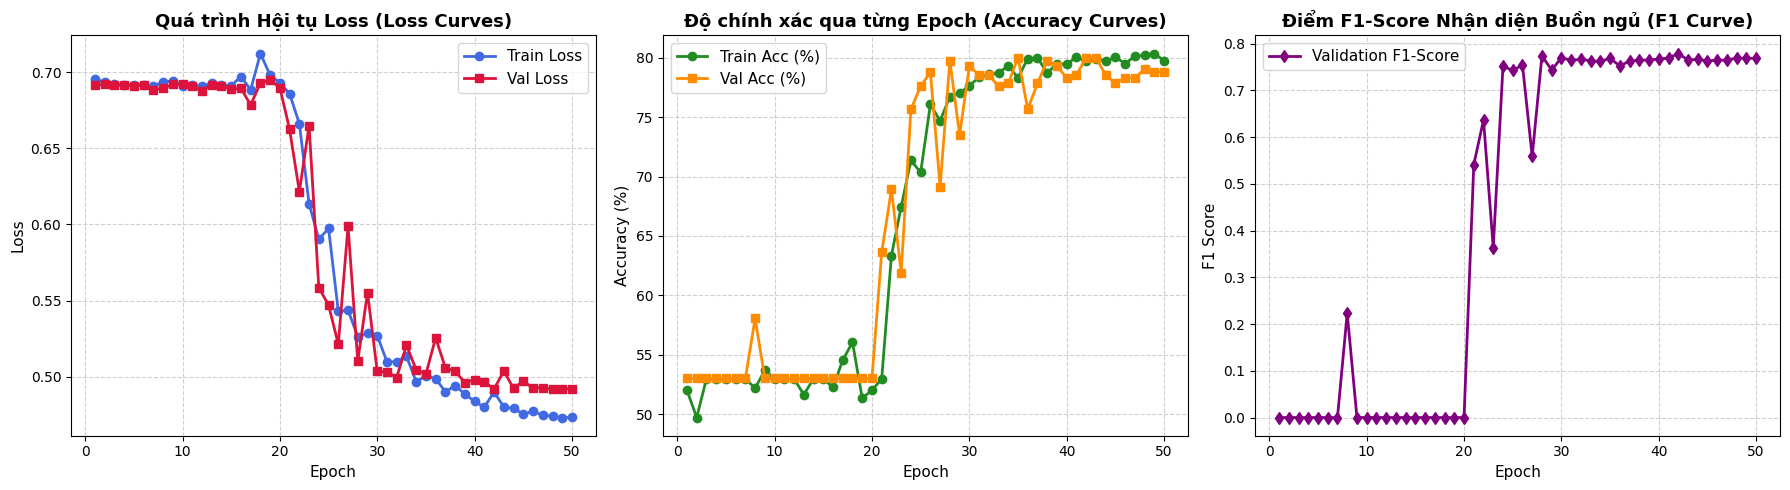

--- ĐÁNH GIÁ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN BEST CHECKPOINT ---
[+] Đã nạp trọng số Best Model: /kaggle/working/checkpoints/best_lstm.pth (Epoch: 35, Val Acc: 80.00%)


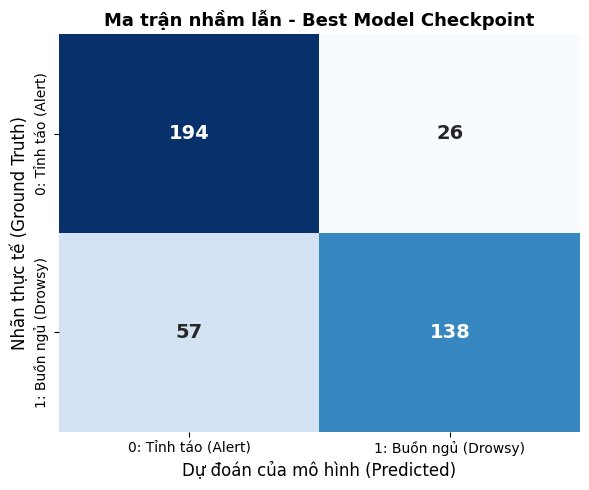

-> Tổng số video đánh giá        : 415
-> Độ chính xác toàn diện (Accuracy): 80.00%
-> Độ chuẩn xác (Precision)      : 84.15%
-> Độ nhạy bắt trúng (Recall)    : 70.77%
-> Điểm F1-Score                 : 0.7688


In [56]:
# ==============================================================================
# CELL 8: TRỰC QUAN HÓA ĐƯỜNG CONG HUẤN LUYỆN & MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# ==============================================================================
if len(history.get("train_loss", [])) > 0:
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Đường cong Loss
    axes[0].plot(epochs_range, history["train_loss"], "o-", label="Train Loss", color="royalblue", linewidth=2)
    axes[0].plot(epochs_range, history["val_loss"], "s-", label="Val Loss", color="crimson", linewidth=2)
    axes[0].set_title("Quá trình Hội tụ Loss (Loss Curves)", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch", fontsize=11)
    axes[0].set_ylabel("Loss", fontsize=11)
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].legend(fontsize=11)

    # 2. Đường cong Accuracy
    axes[1].plot(epochs_range, [a * 100 for a in history["train_acc"]], "o-", label="Train Acc (%)", color="forestgreen", linewidth=2)
    axes[1].plot(epochs_range, [a * 100 for a in history["val_acc"]], "s-", label="Val Acc (%)", color="darkorange", linewidth=2)
    axes[1].set_title("Độ chính xác qua từng Epoch (Accuracy Curves)", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch", fontsize=11)
    axes[1].set_ylabel("Accuracy (%)", fontsize=11)
    axes[1].grid(True, linestyle="--", alpha=0.6)
    axes[1].legend(fontsize=11)

    # 3. Đường cong Điểm F1-Score
    axes[2].plot(epochs_range, history["f1"], "d-", label="Validation F1-Score", color="purple", linewidth=2)
    axes[2].set_title("Điểm F1-Score Nhận diện Buồn ngủ (F1 Curve)", fontsize=13, fontweight="bold")
    axes[2].set_xlabel("Epoch", fontsize=11)
    axes[2].set_ylabel("F1 Score", fontsize=11)
    axes[2].grid(True, linestyle="--", alpha=0.6)
    axes[2].legend(fontsize=11)

    plt.tight_layout()
    plt.show()
else:
    print("[INFO] Không có dữ liệu lịch sử huấn luyện để vẽ đồ thị.")

# ------------------------------------------------------------------------------
# 4. ĐÁNH GIÁ CHI TIẾT TRÊN CHECKPOINT TỐT NHẤT (BEST MODEL EVALUATION)
# ------------------------------------------------------------------------------
print("=" * 75)
print("--- ĐÁNH GIÁ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN BEST CHECKPOINT ---")
print("=" * 75)

best_path = os.path.join(cfg.checkpoint_dir, "best_lstm.pth")
if not os.path.exists(best_path):
    # Fallback sang last_lstm.pth nếu chưa có best_lstm.pth
    best_path = os.path.join(cfg.checkpoint_dir, "last_lstm.pth")

if os.path.exists(best_path):
    try:
        model = DeepLSTMClassifier.from_checkpoint(best_path, map_location=cfg.device)
        print(f"[+] Đã nạp thành công mô hình từ: {best_path} qua `from_checkpoint`")
    except Exception as e:
        print(f"[!] Nạp mô hình qua load_state_dict: {e}")
        ckpt = torch.load(best_path, map_location=cfg.device)
        if "model_state_dict" in ckpt:
            model.load_state_dict(ckpt["model_state_dict"])
        elif isinstance(ckpt, dict):
            model.load_state_dict(ckpt)
    ckpt = torch.load(best_path, map_location=cfg.device)
    val_acc_display = ckpt.get("val_acc", ckpt.get("best_val_acc", 0.0))
    print(f"[+] Trọng số Model: {best_path} (Epoch: {ckpt.get('epoch', 'N/A')}, Val Acc: {val_acc_display*100:.2f}%)")
else:
    print(f"[!] Không tìm thấy checkpoint tại {cfg.checkpoint_dir}, sử dụng trọng số mô hình hiện tại.")

model.eval()
eval_preds, eval_targets = [], []
with torch.no_grad():
    for (p3, p4, p5), labels in val_loader:
        p3, p4, p5 = p3.to(cfg.device), p4.to(cfg.device), p5.to(cfg.device)
        logits = model((p3, p4, p5), return_sequence=False)
        preds = logits.argmax(dim=-1).cpu().numpy()
        eval_preds.extend(preds)
        eval_targets.extend(labels.cpu().numpy())

# Vẽ Heatmap ma trận nhầm lẫn
class_labels = ["0: Tỉnh táo (Alert)", "1: Buồn ngủ (Drowsy)"]
cm_final = confusion_matrix(eval_targets, eval_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels, cbar=False,
            annot_kws={"fontsize": 14, "fontweight": "bold"})
plt.xlabel("Dự đoán của mô hình (Predicted)", fontsize=12)
plt.ylabel("Nhãn thực tế (Ground Truth)", fontsize=12)
plt.title("Ma trận nhầm lẫn - Best Model Checkpoint", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Báo cáo các chỉ số định lượng
tn, fp, fn, tp = cm_final.ravel() if cm_final.size == 4 else (0, 0, 0, 0)
total_samples = len(eval_targets)
acc_final  = (tp + tn) / total_samples if total_samples > 0 else 0
prec_final = tp / (tp + fp) if (tp + fp) > 0 else 0
rec_final  = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_final   = 2 * (prec_final * rec_final) / (prec_final + rec_final) if (prec_final + rec_final) > 0 else 0

print(f"-> Tổng số video đánh giá        : {total_samples}")
print(f"-> Độ chính xác toàn diện (Accuracy): {acc_final * 100:.2f}%")
print(f"-> Độ chuẩn xác (Precision)      : {prec_final * 100:.2f}%")
print(f"-> Độ nhạy bắt trúng (Recall)    : {rec_final * 100:.2f}%")
print(f"-> Điểm F1-Score                 : {f1_final:.4f}")
print("=" * 75)


In [57]:
# ==============================================================================
# CELL 9: ĐÓNG GÓI TOÀN BỘ KẾT QUẢ & TẢI VỀ (EXPORT & DOWNLOAD RESULTS)
# ==============================================================================
# Tự động nén thư mục runs/ (TensorBoard event logs) và các checkpoint mô hình .pth
zip_output_name = "lstm_experiment_results.zip"
zip_path = os.path.join(cfg.output_dir, zip_output_name)

print(f"[+] Đang đóng gói kết quả thí nghiệm vào: {zip_path}...")
import zipfile

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    # 1. Nén toàn bộ log TensorBoard
    if os.path.exists(cfg.log_dir):
        for root, dirs, files in os.walk(cfg.log_dir):
            for file in files:
                file_full = os.path.join(root, file)
                rel_path = os.path.relpath(file_full, cfg.output_dir)
                zipf.write(file_full, rel_path)
    # 2. Nén các checkpoints
    if os.path.exists(cfg.checkpoint_dir):
        for root, dirs, files in os.walk(cfg.checkpoint_dir):
            for file in files:
                file_full = os.path.join(root, file)
                rel_path = os.path.relpath(file_full, cfg.output_dir)
                zipf.write(file_full, rel_path)

zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"[SUCCESS] Đã tạo gói kết quả thành công ({zip_size_mb:.2f} MB): {zip_output_name}")

# Tạo đường link tải trực tiếp trong Kaggle
try:
    from IPython.display import FileLink
    print("\n[+] BẤM VÀO ĐƯỜNG DẪN DƯỚI ĐÂY ĐỂ TẢI TOÀN BỘ KẾT QUẢ VỀ MÁY CÁ NHÂN:")
    display(FileLink(zip_output_name))
except Exception:
    pass

print("\n" + "=" * 75)
print("HƯỚNG DẪN MỞ TENSORBOARD TRÊN MÁY LOCAL VỚI KẾT QUẢ TẢI VỀ:")
print("1. Giải nén file 'lstm_experiment_results.zip' vào thư mục dự án.")
print("2. Mở terminal và chạy lệnh:")
print("   tensorboard --logdir runs")
print("3. Truy cập trình duyệt tại: http://localhost:6006 để xem toàn bộ biểu đồ!")
print("=" * 75)


[+] Đang đóng gói kết quả thí nghiệm vào: /kaggle/working/lstm_experiment_results.zip...
[SUCCESS] Đã tạo gói kết quả thành công (50.97 MB): lstm_experiment_results.zip

[+] BẤM VÀO ĐƯỜNG DẪN DƯỚI ĐÂY ĐỂ TẢI TOÀN BỘ KẾT QUẢ VỀ MÁY CÁ NHÂN:


/kaggle/working/lstm_experiment_results.zip


HƯỚNG DẪN MỞ TENSORBOARD TRÊN MÁY LOCAL VỚI KẾT QUẢ TẢI VỀ:
1. Giải nén file 'lstm_experiment_results.zip' vào thư mục dự án.
2. Mở terminal và chạy lệnh:
   tensorboard --logdir runs
3. Truy cập trình duyệt tại: http://localhost:6006 để xem toàn bộ biểu đồ!
